## Intro

This notebook serves as a testing ground for different models on the data set outlining covid cases in India, the actual report will be included elsewhere.

In [57]:
# Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Model Imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
covid_data = pd.read_csv("covid_dataset.csv")

X_train, X_test, y_train, y_test = train_test_split(covid_data.drop('Has_Covid', axis=1), covid_data['Has_Covid'], test_size=.2, random_state=100)

numeric_features = ['Age','Fever']
categoric_features = ['Gender','Cough','City']

### RFC

In [4]:
numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder()),
    ]
)

# create general preprocessor
preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categoric_features),
    ],
    remainder="drop",
)

pipeline = Pipeline(
    [   
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=100)),
    ]
)

param_grid= {
    'model__n_estimators': [10, 50, 100, 150],
    'model__max_depth': [None, 1, 3, 5, 10, 15],
    'model__min_samples_split': [2, 3, 5, 10],
    'model__criterion': ['gini','entropy', 'log_loss'],
}

In [14]:
model = GridSearchCV(
    pipeline,
    param_grid,
    cv = 5
)
model.fit(X_train, y_train)

,estimator,Pipeline(step..._state=100))])
,param_grid,"{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [None, 1, ...], 'model__min_samples_split': [2, 3, ...], 'model__n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [15]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.45

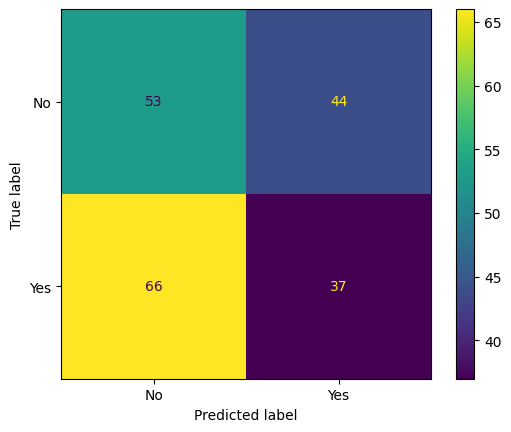

In [16]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(cm,
                                display_labels=model.classes_)
display.plot()
plt.show()

### Log-Reg

In [71]:
translation_map = {'Yes':1, 'No':0}
binary_y_train = [translation_map.get(infected, infected) for infected in y_train]
binary_y_test = [translation_map.get(infected, infected) for infected in y_test]

In [26]:
pipeline_logreg = Pipeline(
    [   
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=100)),
    ]
)

param_grid_logreg = {
    'model__penalty': ['l1','l2'],
    'model__max_iter': [50, 75, 100, 150],
    'model__C': 1 / (10.0 ** np.arange(-3, 1)),
}

model_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid_logreg,
    cv=5
)
_ = model_logreg.fit(X_train,y_train)

c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
80 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-

In [34]:
# get the estimated probabilities on the test set
y_hat = model_logreg.predict_proba(X_test)

# define a range of thresholds
alphas = np.arange(0, 1, 0.01)

# calculate accuracy, precision, and recall for each threshold
accuracies = []
precisions = []
recalls = []
for alpha in alphas:
    # make predictions for a specific threshold
    predictions = (y_hat[:, 1] > alpha).astype(int)
    # calculate and store each metric for a specific threshold
    accuracies.append(accuracy_score(binary_y_test, predictions))
    precisions.append(precision_score(binary_y_test, predictions))
    recalls.append(recall_score(binary_y_test, predictions))

c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diamo\OneDrive\Desktop\cs307\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

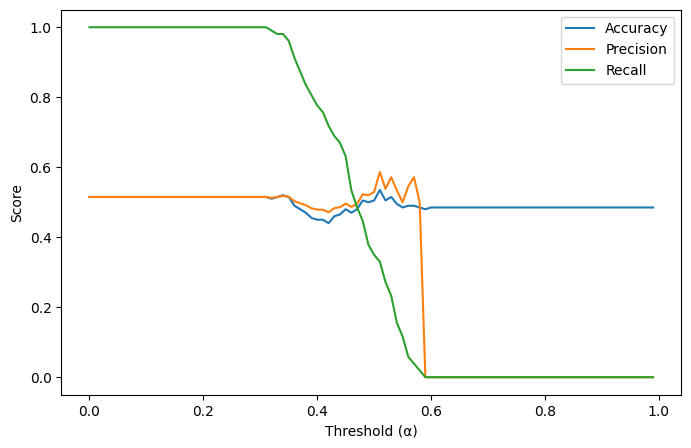

In [36]:
# plot the metrics as a function of the threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, accuracies, label="Accuracy")
ax.plot(alphas, precisions, label="Precision")
ax.plot(alphas, recalls, label="Recall")
ax.set_xlabel("Threshold (α)")
ax.set_ylabel("Score")
ax.legend()
plt.show()

### Pytorch

In [76]:
# get cpu, gpu or mps device for training
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(8, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


# send model to compute device
modelpytorch = NeuralNetwork().to(device)

In [47]:
# define loss function
loss_fn = nn.CrossEntropyLoss()

# define optimizer
optimizer = torch.optim.SGD(
    modelpytorch.parameters(),
    lr=0.1,
)

In [12]:
# define train loop
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [13]:
# define test loop
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [67]:
encoder = OneHotEncoder()
_ = encoder.fit(X_train[categoric_features])
X_train_encoded = encoder.transform(X_train[categoric_features]).todense()
X_test_encoded = encoder.transform(X_test[categoric_features]).todense()

In [87]:
X_train_tensor = torch.tensor(pd.DataFrame(X_train_encoded).values, dtype=torch.float32)
y_train_tensor = torch.tensor(binary_y_train, dtype=torch.long)

X_test_tensor = torch.tensor(pd.DataFrame(X_test_encoded).values, dtype=torch.float32)
y_test_tensor = torch.tensor(binary_y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [88]:
batch_size = 64
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size
)
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 8])
Shape of y: torch.Size([64]) torch.int64


In [91]:
# train model
epochs = 20
for t in range(epochs):
    #print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, modelpytorch, loss_fn, optimizer)
    test(test_dataloader, modelpytorch, loss_fn)
print("Done!")

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800]
Test Error: 
 Accuracy: 0.0%, Avg loss: 2.347275 

loss: 2.350389  [   64/  800